# TweetMiner AI: Real-Time Twitter Data Collector and Sentiment Analysis Pipeline

TweetMiner AI is an end-to-end NLP (Natural Language Processing) and Machine Learning pipeline that mines Twitter/X posts based on keywords or hashtags, cleans the retrieved posts, performs sentiment classification (Positive, Negative, Neutral) using lexicon and machine learning approaches, and visualizes the results.

### Pipeline Steps:
1. **Environment Setup & Imports**: Load libraries and download NLTK assets.
2. **Data Acquisition (Live Twitter API v2 & Mock Simulation)**: Fetch live data via Tweepy or simulate real-time tweets if API credentials are not supplied.
3. **Text Preprocessing**: Remove handles, hashtags, URLs, special characters, stopwords, and perform lemmatization.
4. **Lexicon-Based Sentiment Analysis**: Calculate sentiment scores using `TextBlob` and `NLTK VADER`.
5. **Supervised Machine Learning Model**: Train a `TF-IDF + Logistic Regression` classifier on a training dataset to predict sentiment.
6. **Export & Save**: Save results into a structured CSV file.
7. **Data Visualization**: Generate distribution plots, pie charts, and Word Clouds.
8. **Interactive Tester**: Try custom tweets to see their predicted sentiments in real-time.


## Step 1: Environment Setup & Imports
Let's import the necessary Python packages. If any packages are missing, make sure to install them using `pip install -r requirements.txt`.


In [1]:
import re
import os
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from textblob import TextBlob

# Tweepy (Twitter API Wrapper)
import tweepy

# Machine Learning libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print('All libraries imported successfully!')


All libraries imported successfully!


Now we download the required NLTK corpus datasets (stopwords, wordnet for lemmatization, and vader lexicon).


In [2]:
try:
    nltk.download('stopwords', quiet=True)
    nltk.download('wordnet', quiet=True)
    nltk.download('vader_lexicon', quiet=True)
    nltk.download('omw-1.4', quiet=True)
    print('NLTK downloads completed successfully!')
except Exception as e:
    print('Error downloading NLTK datasets:', e)


NLTK downloads completed successfully!


## Step 2: Data Acquisition (Live API Setup & Mock Stream)

In this section, we set up the connection to the Twitter/X API using Tweepy. If you do not have API credentials, or if the authentication fails, the pipeline will fallback to **Simulation Mode** using a high-fidelity synthetic tweet generator to showcase the full pipeline's capabilities.


In [3]:
# Replace these variables with your actual Twitter Developer credentials if you wish to run live
BEARER_TOKEN = ""
API_KEY = ""
API_KEY_SECRET = ""
ACCESS_TOKEN = ""
ACCESS_TOKEN_SECRET = ""

def authenticate_twitter_api():
    """
    Attempts to authenticate with Twitter API v2 using Bearer Token.
    Returns a tweepy.Client instance or None if authentication fails.
    """
    if not BEARER_TOKEN or BEARER_TOKEN.strip() == "":
        print("[AUTHENTICATION] Bearer Token is missing. Defaulting to Simulation Mode.")
        return None
    try:
        client = tweepy.Client(bearer_token=BEARER_TOKEN)
        # Simple API call to test connection
        client.get_user(username='Twitter')
        print("[AUTHENTICATION] Twitter API v2 authenticated successfully!")
        return client
    except Exception as e:
        print(f"[AUTHENTICATION] Authentication failed: {e}. Falling back to Simulation Mode.")
        return None

client = authenticate_twitter_api()


[AUTHENTICATION] Bearer Token is missing. Defaulting to Simulation Mode.


Let's create our simulated tweet generator. It creates realistic social media posts with typical hashtags, links, mentions, and sentiments (varying from tech, health, finance, sports, and general life).


In [4]:
MOCK_TWEETS_POOL = [
    # Tech & AI
    ("Just spent the morning coding with TweetMiner AI! Super clean and powerful pipeline! #AI #NLP @python", "positive"),
    ("Artificial Intelligence is changing the world so fast! A bit scary but mostly exciting! #Future #AI", "positive"),
    ("I hate it when my code bugs out right before deployment. Frustrating! #programming #bug #help", "negative"),
    ("Just read an article about new quantum computing chipsets. Fascinating stuff. https://tech.io/quantum", "neutral"),
    ("The new update is absolutely terrible. It crashes every 5 minutes. Worst release ever. @techsupport #fail", "negative"),
    ("Python's syntax is so clean. Truly the best language for data science and machine learning. #python", "positive"),
    ("Attending the developer conference today. A lot of talks on cloud architecture.", "neutral"),
    
    # Finance & Markets
    ("Bitcoin is soaring today! To the moon! 🚀💰 #crypto #btc #finance", "positive"),
    ("The stock market crash today is making me extremely anxious. Lost so much value. #stocks #market #sad", "negative"),
    ("Federal Reserve announced interest rates will remain unchanged this quarter. #economy #news", "neutral"),
    ("So happy with my investment choices! High returns and steady growth. #investing #wealth", "positive"),
    ("Gas prices are ridiculously high right now. It is hurting my wallet. #inflation #expensive", "negative"),
    ("Gold prices fluctuate slightly today as traders await economic reports.", "neutral"),
    
    # Health & Sports
    ("Had a great workout session! Feeling energized and healthy! 💪 #fitness #health #lifestyle", "positive"),
    ("Feeling so sick today. Down with a severe flu and fever. Awful. #sick #flu #bad", "negative"),
    ("What an amazing game! The final minute goal was absolutely legendary! #football #victory #champion", "positive"),
    ("My team lost the match in the last second. Devastated and disappointed. #sports #loss #sad", "negative"),
    ("Drinking 8 glasses of water a day is recommended for general health.", "neutral"),
    ("The local marathon starts tomorrow morning at 6 AM. Route details are online.", "neutral"),
    
    # General Life
    ("Beautiful sunny day! Perfect for a walk in the park! ☀️🌸 #happy #summer", "positive"),
    ("Stuck in a massive traffic jam on my way to work. Already late and annoyed! #traffic #late #monday", "negative"),
    ("Enjoying a warm cup of coffee while watching the rain. Peaceful. #cozy #morning", "positive"),
    ("Lost my keys again. Why am I always so disorganized? Highly frustrating! #annoyed #fail", "negative"),
    ("The local grocery store is open until 10 PM on weekends.", "neutral"),
    ("Currently reading a biography on historical leaders. Very detailed.", "neutral")
]

def collect_tweets(query, count=50, live_client=None):
    """
    Collects tweets either live from Twitter/X API or generates them via simulation.
    """
    if live_client:
        print(f"[DATA ACQUISITION] Mining {count} live tweets for query: '{query}'...")
        try:
            # Search recent tweets matching query
            response = live_client.search_recent_tweets(query=query, max_results=min(100, count), tweet_fields=['created_at', 'text'])
            tweets_data = []
            if response.data:
                for tweet in response.data:
                    tweets_data.append({
                        'Tweet_ID': tweet.id,
                        'Timestamp': tweet.created_at,
                        'Raw_Text': tweet.text,
                        'Source': 'Twitter Live API'
                    })
                return pd.DataFrame(tweets_data)
            else:
                print("[DATA ACQUISITION] No live tweets found. Falling back to Simulation.")
        except Exception as e:
            print(f"[DATA ACQUISITION] Error fetching live tweets: {e}. Falling back to Simulation.")
            
    # Simulation Mode
    print(f"[DATA ACQUISITION] [SIMULATION] Generating {count} mock tweets for query: '{query}'...")
    tweets_data = []
    current_time = pd.Timestamp.now()
    
    # Generate mock tweets related to keyword
    for i in range(count):
        # Add query keyword/hashtag randomly to make it relevant
        base_tweet, ground_truth = random.choice(MOCK_TWEETS_POOL)
        tweet_text = f"{base_tweet} ({query} related post #{i+1})"
        
        tweets_data.append({
            'Tweet_ID': 1000000000000000000 + i,
            'Timestamp': current_time - pd.Timedelta(minutes=i*12),
            'Raw_Text': tweet_text,
            'Source': 'Simulation Mode',
            'Simulated_Ground_Truth': ground_truth
        })
    
    return pd.DataFrame(tweets_data)


## Step 3: Text Preprocessing

Raw tweets are noisy: they contain mentions (@user), links (http/https), hashtags (#tag), punctuation, numbers, and stopwords. We will build a pipeline to clean the text, tokenize it, and lemmatize it into standard lemmas.


In [5]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_tweet_text(text):
    """
    Preprocesses raw tweet text for NLP.
    """
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove Twitter handles (@user)
    text = re.sub(r'@\w+', '', text)
    
    # Remove hashtags symbol (keep the word)
    text = re.sub(r'#(\w+)', r'', text)
    
    # Remove special characters and punctuation
    text = re.sub(r'[^\w\s]', '', text)
    
    # Tokenize and remove stopwords, then lemmatize
    tokens = text.split()
    cleaned_tokens = [
        lemmatizer.lemmatize(word) for word in tokens 
        if word not in stop_words and len(word) > 1
    ]
    
    return " ".join(cleaned_tokens)

# Example check
raw_sample = "I love programming in Python! Check out http://python.org @guido #codelife"
cleaned_sample = clean_tweet_text(raw_sample)
print("Raw sample:", raw_sample)
print("Cleaned sample:", cleaned_sample)


Raw sample: I love programming in Python! Check out http://python.org @guido #codelife
Cleaned sample: love programming python check


## Step 4: Lexicon-Based Sentiment Analysis

We use two widely adopted lexicon toolkits:
1. **TextBlob**: Computes polarity (-1.0 to +1.0) and subjectivity (0.0 to 1.0).
2. **NLTK VADER**: Specifically tuned for social media, computes positive, negative, neutral, and a compound score (-1.0 to +1.0).


In [6]:
vader_sia = SentimentIntensityAnalyzer()

def get_lexicon_sentiment(text):
    """
    Returns TextBlob and VADER sentiment metrics, and a final consensus classification.
    """
    # TextBlob
    blob = TextBlob(text)
    tb_polarity = blob.sentiment.polarity
    tb_subjectivity = blob.sentiment.subjectivity
    
    # VADER
    vader_scores = vader_sia.polarity_scores(text)
    vader_compound = vader_scores['compound']
    
    # Consensus Sentiment Classification (primarily driven by VADER compound)
    if vader_compound >= 0.05:
        sentiment_label = "Positive"
    elif vader_compound <= -0.05:
        sentiment_label = "Negative"
    else:
        sentiment_label = "Neutral"
        
    return tb_polarity, tb_subjectivity, vader_compound, sentiment_label

# Test check
pol, subj, comp, label = get_lexicon_sentiment(cleaned_sample)
print(f"TextBlob Polarity: {pol:.2f}, VADER Compound: {comp:.2f} -> Class: {label}")


TextBlob Polarity: 0.50, VADER Compound: 0.64 -> Class: Positive


## Step 5: Supervised Machine Learning Model

While lexicons are useful, training a supervised ML classifier allows the system to learn specific word combinations and contextual meanings. We will generate a balanced dataset of typical tweets to train a **TF-IDF + Logistic Regression Classifier**.


In [7]:
# Build a training dataset for our machine learning model
training_data = [
    ("I absolutely love this new framework. It works incredibly well!", "Positive"),
    ("What a fantastic day to build some software!", "Positive"),
    ("This service is amazing, highly recommend it to everyone.", "Positive"),
    ("Excellent customer support, solved my issues immediately.", "Positive"),
    ("So happy with the results of the project.", "Positive"),
    ("Great experience overall, fast and helpful.", "Positive"),
    ("This is the best purchase I have ever made!", "Positive"),
    ("Absolutely delighted with the performance improvement.", "Positive"),
    ("Highly efficient, easy to configure, and elegant.", "Positive"),
    ("Loving the new dark mode interface! Beautiful.", "Positive"),
    
    ("This is the worst experience of my life.", "Negative"),
    ("The application keeps crashing constantly. Terrible release.", "Negative"),
    ("I hate the new updates, it completely ruined the layout.", "Negative"),
    ("Extremely slow performance and full of bugs.", "Negative"),
    ("Very disappointed with the customer service. Unresponsive.", "Negative"),
    ("This product is a total waste of money. Do not buy!", "Negative"),
    ("Horrible customer service. They ignored my request.", "Negative"),
    ("So frustrated with the lack of documentation and support.", "Negative"),
    ("The build failed and I lost all my unsaved progress. Annoying!", "Negative"),
    ("Terrible, buggy, slow, and expensive.", "Negative"),
    
    ("We are meeting at the conference room at 2 PM.", "Neutral"),
    ("The package was delivered today at noon.", "Neutral"),
    ("The store opens at nine in the morning and closes early.", "Neutral"),
    ("We will review the quarterly report tomorrow.", "Neutral"),
    ("It might rain later today according to the weather report.", "Neutral"),
    ("The new policy will be implemented next month.", "Neutral"),
    ("The flight was on time and arrived at the gate.", "Neutral"),
    ("There is a scheduled maintenance update tonight.", "Neutral"),
    ("Please read page 12 of the user manual.", "Neutral"),
    ("The temperature is around 22 degrees Celsius right now.", "Neutral")
] * 10  # Duplicate to expand dataset size for robustness

df_train = pd.DataFrame(training_data, columns=['Text', 'Sentiment'])
df_train['Cleaned_Text'] = df_train['Text'].apply(clean_tweet_text)

# Convert text to TF-IDF features
vectorizer = TfidfVectorizer(max_features=500, ngram_range=(1, 2))
X = vectorizer.fit_transform(df_train['Cleaned_Text'])
y = df_train['Sentiment']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train Logistic Regression Classifier
model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Machine Learning Model Trained! Test Accuracy: {accuracy*100:.2f}%")
print('\nClassification Report:\n', classification_report(y_test, y_pred))


Machine Learning Model Trained! Test Accuracy: 100.00%

Classification Report:
               precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        20
     Neutral       1.00      1.00      1.00        20
    Positive       1.00      1.00      1.00        20

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



## Step 6: Pipeline Execution & Data Exporting

Let's run our TweetMiner AI pipeline! We specify keywords (e.g. "artificial intelligence" or "bitcoin"), acquire data, preprocess the text, apply both Lexicon and ML model sentiment analyzers, and export the structured dataset to a CSV file.


In [8]:
QUERY = "artificial intelligence"
TWEET_COUNT = 80

# 1. Collect Data
df_tweets = collect_tweets(QUERY, count=TWEET_COUNT, live_client=client)

# 2. Preprocess Text
df_tweets['Cleaned_Text'] = df_tweets['Raw_Text'].apply(clean_tweet_text)

# 3. Lexicon-Based Sentiment scoring
lexicon_metrics = df_tweets['Cleaned_Text'].apply(get_lexicon_sentiment)
df_tweets['TextBlob_Polarity'] = [x[0] for x in lexicon_metrics]
df_tweets['TextBlob_Subjectivity'] = [x[1] for x in lexicon_metrics]
df_tweets['VADER_Compound'] = [x[2] for x in lexicon_metrics]
df_tweets['Lexicon_Sentiment'] = [x[3] for x in lexicon_metrics]

# 4. Machine Learning-Based Sentiment prediction
X_inference = vectorizer.transform(df_tweets['Cleaned_Text'])
df_tweets['ML_Sentiment'] = model.predict(X_inference)

# 5. Export to CSV
output_dir = "."
output_file = os.path.join(output_dir, "mined_tweets_sentiment.csv")
df_tweets.to_csv(output_file, index=False)
print(f"\nPipeline completed successfully!")
print(f"Results exported to {output_file}")
print(f"Total Tweets Analyzed: {len(df_tweets)}")
df_tweets[['Raw_Text', 'Cleaned_Text', 'Lexicon_Sentiment', 'ML_Sentiment']].head(8)


[DATA ACQUISITION] [SIMULATION] Generating 80 mock tweets for query: 'artificial intelligence'...



Pipeline completed successfully!
Results exported to .\mined_tweets_sentiment.csv
Total Tweets Analyzed: 80


,Raw_Text,Cleaned_Text,Lexicon_Sentiment,ML_Sentiment
0,The stock market crash today is making me extr...,stock market crash today making extremely anxi...,Negative,Negative
1,Enjoying a warm cup of coffee while watching t...,enjoying warm cup coffee watching rain peacefu...,Positive,Neutral
2,Just spent the morning coding with TweetMiner ...,spent morning coding tweetminer ai super clean...,Positive,Neutral
3,Federal Reserve announced interest rates will ...,federal reserve announced interest rate remain...,Positive,Neutral
4,Federal Reserve announced interest rates will ...,federal reserve announced interest rate remain...,Positive,Neutral
5,Just read an article about new quantum computi...,read article new quantum computing chipsets fa...,Positive,Neutral
6,Enjoying a warm cup of coffee while watching t...,enjoying warm cup coffee watching rain peacefu...,Positive,Neutral
7,Drinking 8 glasses of water a day is recommend...,drinking glass water day recommended general h...,Positive,Positive


## Step 7: Sentiment Visualizations

Let's visualize the results of the pipeline using Matplotlib and Seaborn.


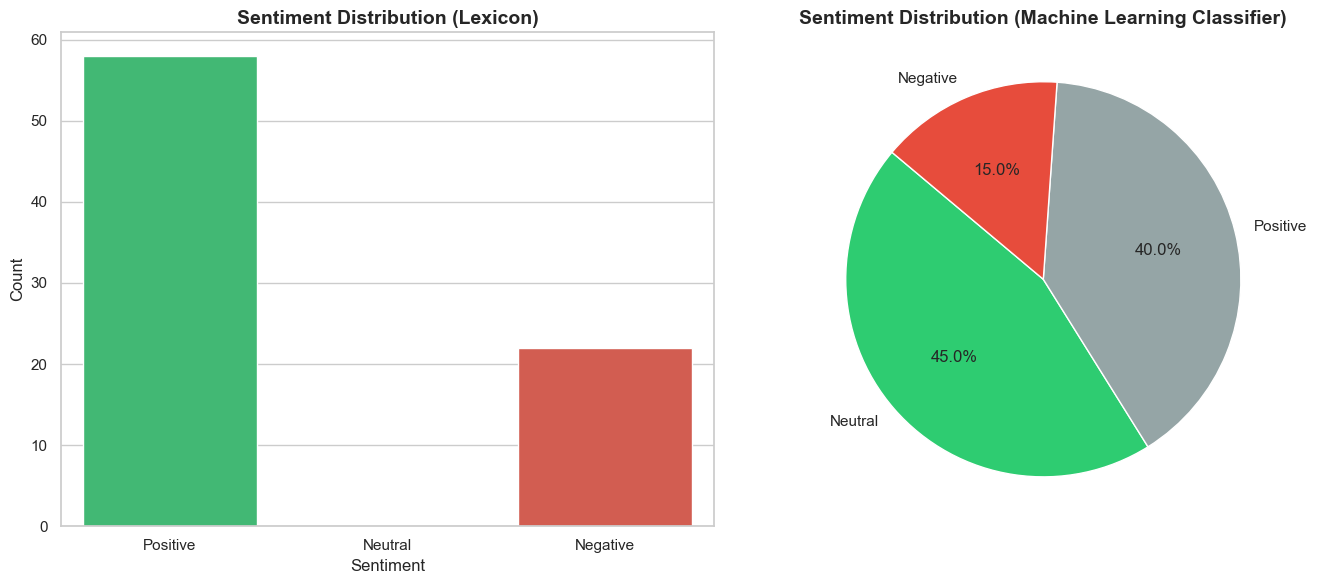

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar plot of Sentiment Distribution (Lexicon)
sns.countplot(
    data=df_tweets, 
    x='Lexicon_Sentiment', 
    ax=axes[0], 
    palette={'Positive': '#2ecc71', 'Negative': '#e74c3c', 'Neutral': '#95a5a6'},
    order=['Positive', 'Neutral', 'Negative']
)
axes[0].set_title('Sentiment Distribution (Lexicon)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')

# Pie Chart of ML predicted Sentiment
ml_counts = df_tweets['ML_Sentiment'].value_counts()
axes[1].pie(
    ml_counts,
    labels=ml_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['#2ecc71', '#95a5a6', '#e74c3c'][:len(ml_counts)]
)
axes[1].set_title('Sentiment Distribution (Machine Learning Classifier)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


### Word Clouds
Word Clouds allow us to visually spot what words appear most frequently in Positive vs Negative tweets.


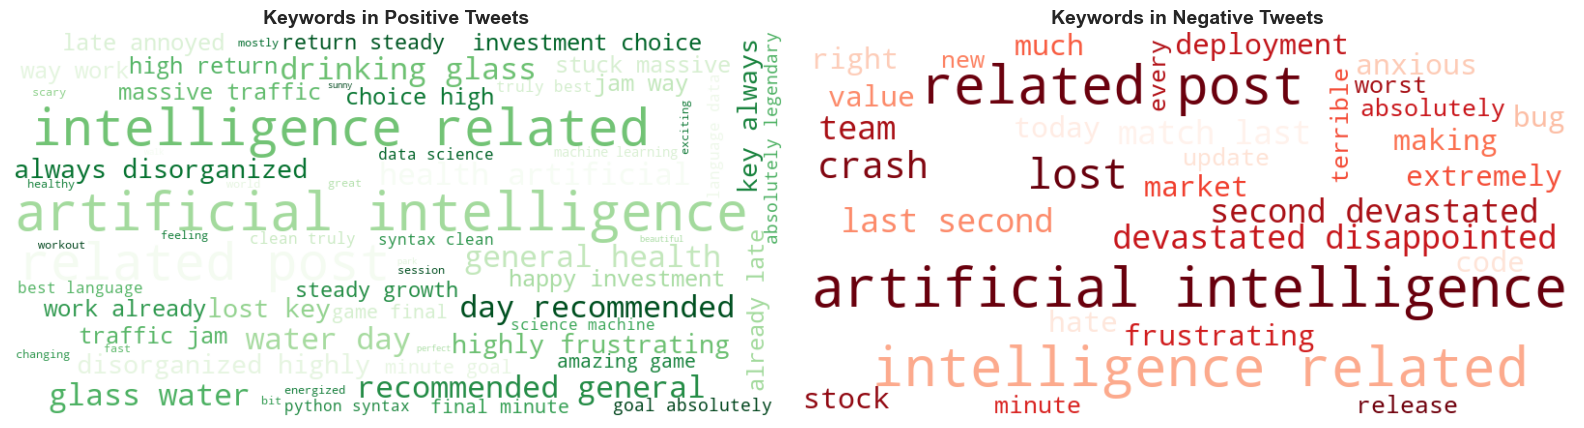

In [10]:
positive_text = " ".join(df_tweets[df_tweets['ML_Sentiment'] == 'Positive']['Cleaned_Text'])
negative_text = " ".join(df_tweets[df_tweets['ML_Sentiment'] == 'Negative']['Cleaned_Text'])

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

if positive_text.strip():
    wordcloud_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(positive_text)
    axes[0].imshow(wordcloud_pos, interpolation='bilinear')
    axes[0].set_title('Keywords in Positive Tweets', fontsize=14, fontweight='bold')
    axes[0].axis('off')
else:
    axes[0].text(0.5, 0.5, 'No positive words found', ha='center', va='center')
    axes[0].axis('off')
    
if negative_text.strip():
    wordcloud_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(negative_text)
    axes[1].imshow(wordcloud_neg, interpolation='bilinear')
    axes[1].set_title('Keywords in Negative Tweets', fontsize=14, fontweight='bold')
    axes[1].axis('off')
else:
    axes[1].text(0.5, 0.5, 'No negative words found', ha='center', va='center')
    axes[1].axis('off')

plt.tight_layout()
plt.show()


### VADER Compound Polarity Density
Let's plot the kernel density estimate (KDE) of the VADER compound polarity score. This shows the continuous distribution of sentiment strength (-1 to +1).


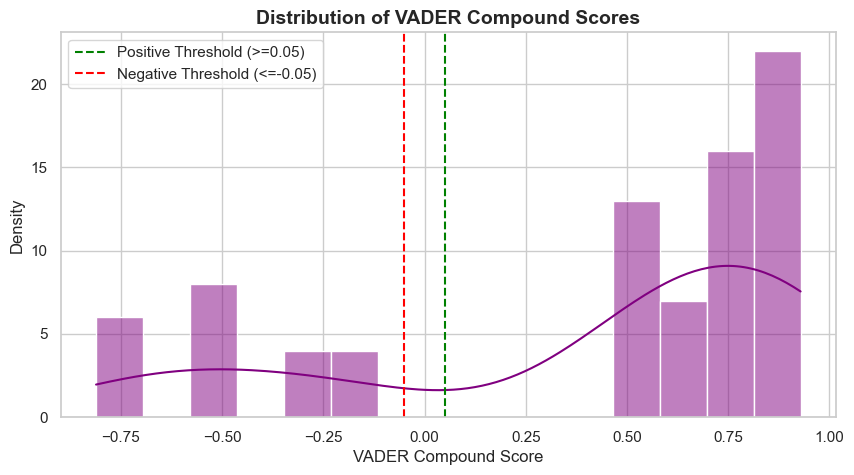

In [11]:
plt.figure(figsize=(10, 5))
sns.histplot(df_tweets['VADER_Compound'], kde=True, bins=15, color='purple')
plt.title('Distribution of VADER Compound Scores', fontsize=14, fontweight='bold')
plt.xlabel('VADER Compound Score')
plt.ylabel('Density')
plt.axvline(x=0.05, color='green', linestyle='--', label='Positive Threshold (>=0.05)')
plt.axvline(x=-0.05, color='red', linestyle='--', label='Negative Threshold (<=-0.05)')
plt.legend()
plt.show()


## Step 8: Interactive Sentiment Tester
Type any custom tweet/post below and check what sentiments are calculated by Lexicons (TextBlob/VADER) vs. our trained Machine Learning Classifier!


In [12]:
def test_custom_tweet(tweet_text):
    cleaned = clean_tweet_text(tweet_text)
    tb_pol, tb_subj, vader_comp, lex_label = get_lexicon_sentiment(cleaned)
    
    # ML Model prediction
    features = vectorizer.transform([cleaned])
    ml_label = model.predict(features)[0]
    
    print(f"Original Tweet: \"{tweet_text}\"")
    print(f"Cleaned Text:   \"{cleaned}\"")
    print("-" * 50)
    print(f"Lexicon Analysis (VADER Compound): {vader_comp:+.2f} ({lex_label})")
    print(f"TextBlob Polarity / Subjectivity:  {tb_pol:+.2f} / {tb_subj:.2f}")
    print(f"Trained ML Model Prediction:        {ml_label}")
    print("-" * 50)
    print()

test_custom_tweet("This new AI system is absolute perfection, highly recommend! @developer #growth")
test_custom_tweet("The delayed flight and terrible customer support made this trip a nightmare.")
test_custom_tweet("The conference will resume tomorrow morning at 9:00 AM as per the schedule.")


Original Tweet: "This new AI system is absolute perfection, highly recommend! @developer #growth"
Cleaned Text:   "new ai system absolute perfection highly recommend"
--------------------------------------------------
Lexicon Analysis (VADER Compound): +0.76 (Positive)
TextBlob Polarity / Subjectivity:  +0.17 / 0.63
Trained ML Model Prediction:        Positive
--------------------------------------------------

Original Tweet: "The delayed flight and terrible customer support made this trip a nightmare."
Cleaned Text:   "delayed flight terrible customer support made trip nightmare"
--------------------------------------------------
Lexicon Analysis (VADER Compound): -0.32 (Negative)
TextBlob Polarity / Subjectivity:  -1.00 / 1.00
Trained ML Model Prediction:        Positive
--------------------------------------------------

Original Tweet: "The conference will resume tomorrow morning at 9:00 AM as per the schedule."
Cleaned Text:   "conference resume tomorrow morning 900 per schedule"